In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('titanic.csv')

In [4]:
df.sample(10)

,Cabin,Ticket,number,Survived
467,NaN,113792,1,0
534,NaN,315084,6,0
447,NaN,113794,2,1
315,NaN,347470,5,1
868,NaN,345777,A,0
624,NaN,54636,A,0
285,NaN,349239,4,0
714,NaN,250647,1,0
306,NaN,17421,4,1
91,NaN,347466,3,0


In [5]:
df['number'].unique()

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

Text(0.5, 1.0, 'passengers Traveling wiht ')

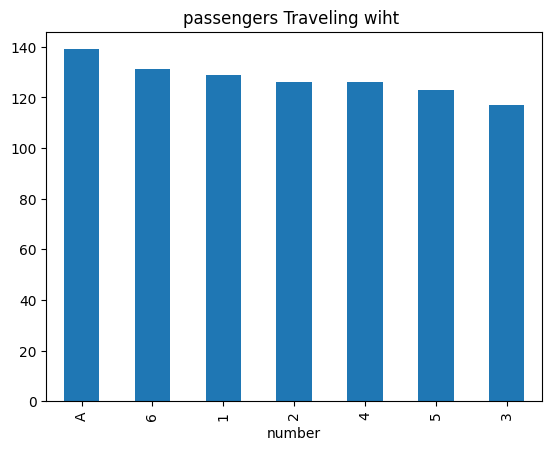

In [9]:
fig = df['number'].value_counts().plot(kind='bar')
fig.set_title('passengers Traveling wiht ')

In [10]:
#extract numerical part 
df['number_numeric']= pd.to_numeric(df['number'], errors='coerce', downcast='integer')

In [11]:
#extract categorical part
df['number_categorical']=np.where(df['number_numeric'].isnull(), df['number'],np.nan)

In [12]:
df.sample(10)

,Cabin,Ticket,number,Survived,number_numeric,number_categorical
825,NaN,368323,2,0,2.0,NaN
802,B96 B98,113760,6,1,6.0,NaN
414,NaN,STON/O 2. 3101269,6,1,6.0,NaN
46,NaN,370371,3,0,3.0,NaN
344,NaN,229236,2,0,2.0,NaN
527,C95,PC 17483,2,0,2.0,NaN
353,NaN,349237,5,0,5.0,NaN
415,NaN,343095,A,0,NaN,A
642,NaN,347088,A,0,NaN,A
648,NaN,S.O./P.P. 751,2,0,2.0,NaN


In [13]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [15]:
df['Ticket'].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

In [17]:
df['cabin_num']= df['Cabin'].str.extract('(\d+)')

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\bhavy\AppData\Local\Temp\ipykernel_23712\3375616705.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['cabin_num']= df['Cabin'].str.extract('(\d+)')


In [18]:
df['cabin_cat'] = df['Cabin'].str[0]

In [19]:
df.head()

,Cabin,Ticket,number,Survived,number_numeric,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

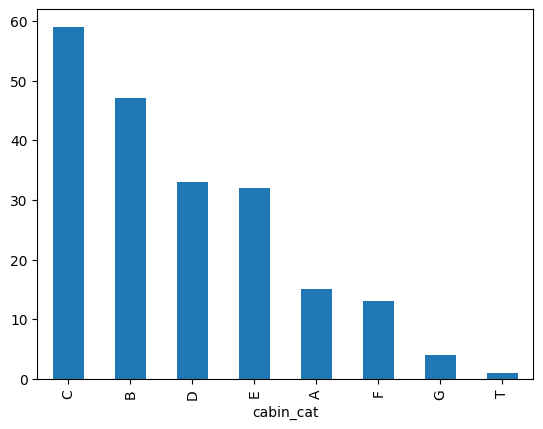

In [21]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [22]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

df.head(20)

,Cabin,Ticket,number,Survived,number_numeric,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN
